Saving PCDprobe_Harmonic_Features.csv to PCDprobe_Harmonic_Features (15).csv
Renamed columns:
  H6_power -> H6_dB
  H7_power -> H7_dB
  H8_power -> H8_dB
  H9_power -> H9_dB
  H10_power -> H10_dB
  H11_power -> H11_dB
  H12_power -> H12_dB
  U6.5_freq -> U6_freq
  U6.5_db -> U6_db
  U6.5_power -> U6_dB
  U7.5_freq -> U7_freq
  U7.5_db -> U7_db
  U7.5_power -> U7_dB
  U8.5_freq -> U8_freq
  U8.5_db -> U8_db
  U8.5_power -> U8_dB
  U9.5_freq -> U9_freq
  U9.5_db -> U9_db
  U9.5_power -> U9_dB
  U10.5_freq -> U10_freq
  U10.5_db -> U10_db
  U10.5_power -> U10_dB
  U11.5_freq -> U11_freq
  U11.5_db -> U11_db
  U11.5_power -> U11_dB
  U12.5_freq -> U12_freq
  U12.5_db -> U12_db
  U12.5_power -> U12_dB

Rows: 192
Features: 48
Target: Unsafe_1s
Positive rate: 10.9%

Metric table:
       Model  Sensitivity  Specificity
0    XGBoost        1.000        0.942
1        SVM        0.952        0.953
2  KNN (k=5)        0.905        1.000


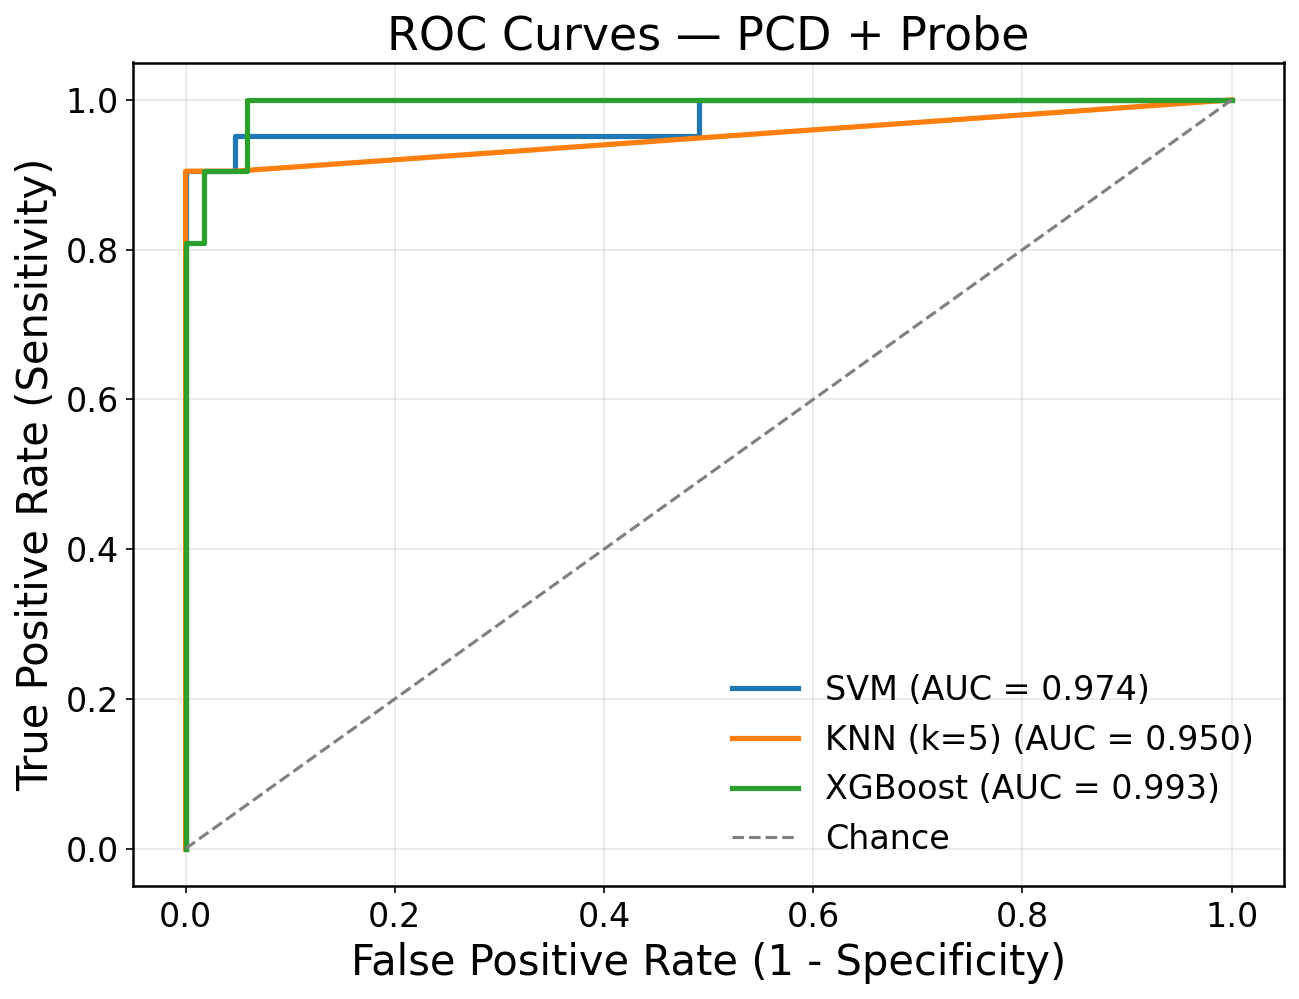

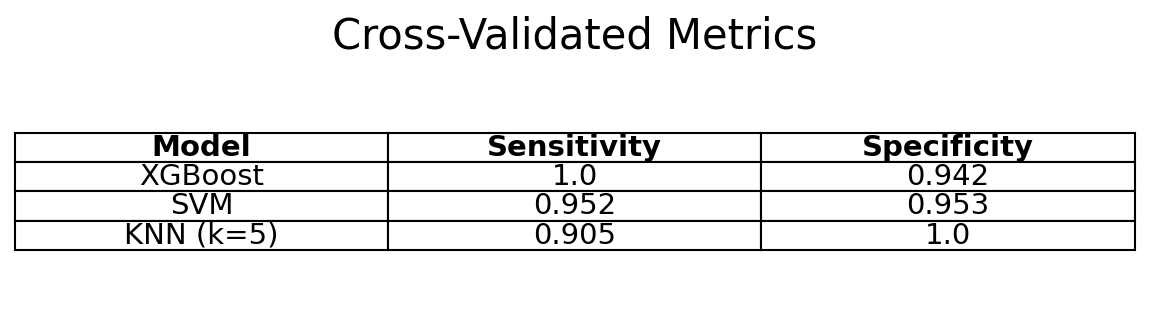

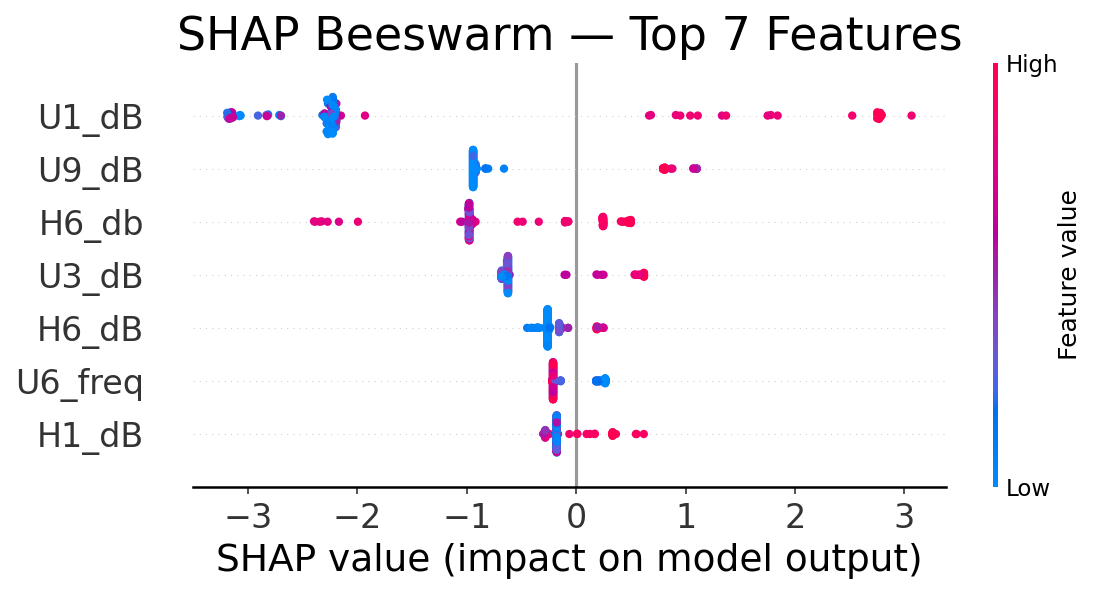

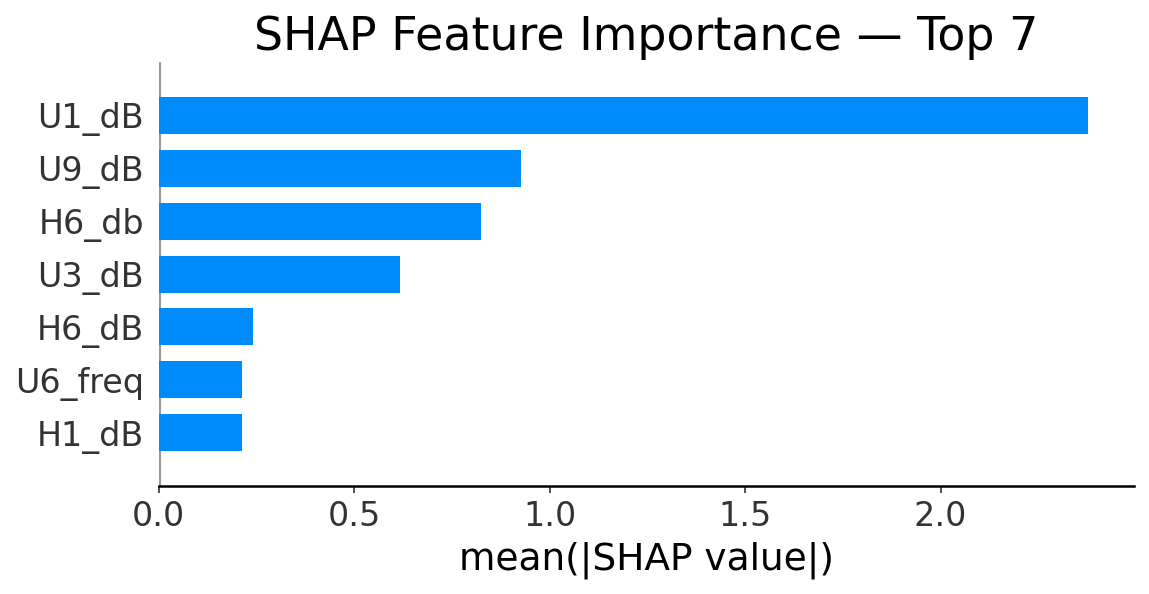


Top 7 Features:
 Rank Feature  Mean_Abs_SHAP
    1   U1_dB       2.375952
    2   U9_dB       0.927869
    3   H6_db       0.824050
    4   U3_dB       0.617168
    5   H6_dB       0.241414
    6 U6_freq       0.213739
    7   H1_dB       0.212786


In [ ]:
!pip -q install shap xgboost

import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, f1_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb
import shap

# -------------------------
# SETTINGS
# -------------------------
TARGET_SENSITIVITY = 0.94
N_SPLITS = 5
RANDOM_STATE = 42

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 1.2
})

# -------------------------
# UPLOAD CSV
# -------------------------
uploaded = files.upload()
if len(uploaded) == 0:
    raise ValueError("No file uploaded.")

csv_name = list(uploaded.keys())[0]
CSV_PATH = f"/content/{csv_name}"
df = pd.read_csv(CSV_PATH)

# -------------------------
# RENAME COLUMNS
# -------------------------
# Step 1: _power → _dB
rename_map = {}
for col in df.columns:
    new_col = col
    if '_power' in col.lower():
        new_col = col.replace('_power', '_dB').replace('_Power', '_dB')
    rename_map[col] = new_col
df = df.rename(columns=rename_map)

# Step 2: remove .5 from U labels (U1.5_dB → U1_dB, U9.5_dB → U9_dB)
rename_u = {}
for col in df.columns:
    new_col = col
    m = re.match(r'^(.*U)(\d+)\.5(.*)$', col)
    if m:
        new_col = m.group(1) + m.group(2) + m.group(3)
    rename_u[col] = new_col
df = df.rename(columns=rename_u)

# Print what changed
all_renamed = {k: rename_u.get(rename_map.get(k, k), rename_map.get(k, k)) for k in rename_map}
changed = [(k, v) for k, v in all_renamed.items() if k != v]
if changed:
    print("Renamed columns:")
    for old, new in changed:
        print(f"  {old} -> {new}")

# -------------------------
# DYNAMIC TARGET DETECTION
# -------------------------
target_col = None
for c in df.columns:
    if c.strip().lower() == "unsafe_1s":
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Could not find target column Unsafe_1s. Found: {list(df.columns)}")

# -------------------------
# DYNAMIC FEATURE DETECTION
# -------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found.")

data = df[feature_cols + [target_col]].copy()
data = data.dropna(subset=[target_col])

X = data[feature_cols].copy()
y = data[target_col].astype(int).copy()

unique_y = sorted(pd.Series(y).dropna().unique().tolist())
if not set(unique_y).issubset({0, 1}):
    raise ValueError(f"Target must be binary 0/1. Found: {unique_y}")

# -------------------------
# TRANSFORM FEATURES
# -------------------------
def transform_features(X_df):
    X_out = X_df.copy()
    for col in X_out.columns:
        vals = pd.to_numeric(X_out[col], errors="coerce").astype(float)
        if "power" in col.lower():
            min_val = np.nanmin(vals)
            if min_val <= 0:
                vals = vals - min_val + 1e-12
            else:
                vals = vals + 1e-12
            vals = np.log10(vals)
        X_out[col] = vals
    return X_out

X = transform_features(X)

print(f"\nRows: {len(X)}")
print(f"Features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"Positive rate: {(y==1).mean():.1%}")

# -------------------------
# MODELS
# -------------------------
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

knn_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

n_neg = int((y == 0).sum())
n_pos = int((y == 1).sum())
scale_pos_weight = n_neg / max(n_pos, 1)

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", xgb.XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight
    ))
])

models = {
    "SVM": svm_model,
    "KNN (k=5)": knn_model,
    "XGBoost": xgb_model
}

# -------------------------
# HELPERS
# -------------------------
def choose_threshold_for_target_sensitivity(y_true, y_prob, target_sens=0.94):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite_mask = np.isfinite(thresholds)
    fpr = fpr[finite_mask]
    tpr = tpr[finite_mask]
    thresholds = thresholds[finite_mask]
    valid = np.where(tpr >= target_sens)[0]
    if len(valid) > 0:
        best_idx = valid[np.argmax(thresholds[valid])]
    else:
        j = tpr - fpr
        best_idx = np.argmax(j)
    return thresholds[best_idx], fpr[best_idx], tpr[best_idx]

def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = precision_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_prob)
    return {
        "AUC": auc_score, "Sensitivity": sensitivity,
        "Specificity": specificity, "Precision": precision,
        "Accuracy": accuracy, "F1 Score": f1,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    }

# -------------------------
# OOF PREDICTIONS
# -------------------------
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

results = []
roc_data = {}

for model_name, model in models.items():
    y_prob_oof = np.zeros(len(y), dtype=float)
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        model.fit(X_train, y_train)
        y_prob_oof[test_idx] = model.predict_proba(X_test)[:, 1]

    best_thresh, op_fpr, op_tpr = choose_threshold_for_target_sensitivity(
        y_true=y.values, y_prob=y_prob_oof, target_sens=TARGET_SENSITIVITY)

    # KNN doesn't handle class imbalance well with low thresholds
    # Use Youden's J (optimal balance) instead of target sensitivity
    if model_name == "KNN (k=5)":
        fpr_tmp, tpr_tmp, thresh_tmp = roc_curve(y.values, y_prob_oof)
        finite = np.isfinite(thresh_tmp)
        j_scores = tpr_tmp[finite] - fpr_tmp[finite]
        best_j = np.argmax(j_scores)
        best_thresh = thresh_tmp[finite][best_j]
        op_fpr = fpr_tmp[finite][best_j]
        op_tpr = tpr_tmp[finite][best_j]

    metrics = compute_metrics(y.values, y_prob_oof, best_thresh)
    metrics["Model"] = model_name
    metrics["Threshold"] = best_thresh
    results.append(metrics)

    fpr, tpr, _ = roc_curve(y.values, y_prob_oof)
    roc_data[model_name] = {
        "fpr": fpr, "tpr": tpr, "auc": metrics["AUC"],
        "threshold": best_thresh, "op_fpr": op_fpr, "op_tpr": op_tpr
    }

metrics_df = pd.DataFrame(results).sort_values(
    ["Sensitivity", "Specificity", "AUC"], ascending=[False, False, False]
).reset_index(drop=True)

metrics_table = metrics_df.copy()
for col in ["Threshold","AUC","Sensitivity","Specificity","Precision","Accuracy","F1 Score"]:
    metrics_table[col] = metrics_table[col].round(3)

print("\nMetric table:")
print(metrics_table[["Model", "Sensitivity", "Specificity"]])

# -------------------------
# ROC PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(9, 7))
for model_name in ["SVM", "KNN (k=5)", "XGBoost"]:
    d = roc_data[model_name]
    ax.plot(d["fpr"], d["tpr"], linewidth=2.5,
            label=f'{model_name} (AUC = {d["auc"]:.3f})')

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="gray", label="Chance")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curves — PCD + Probe")
ax.legend(loc="lower right", frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# METRIC TABLE FIGURE
# -------------------------
fig, ax = plt.subplots(figsize=(8, 0.6 + 0.6 * len(metrics_table)))
ax.axis("off")
display_cols = ["Model", "Sensitivity", "Specificity"]
table_data = metrics_table[display_cols]
tbl = ax.table(cellText=table_data.values, colLabels=table_data.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(0.14)
plt.title("Cross-Validated Metrics", fontsize=20, pad=20)
plt.tight_layout()
plt.show()

# -------------------------
# FINAL XGBOOST + SHAP
# -------------------------
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns)

xgb_full = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric="logloss", random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight)
xgb_full.fit(X_scaled, y)

explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_scaled)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_k = 7
top_idx = np.argsort(mean_abs_shap)[::-1][:top_k]
X_top = X_scaled.iloc[:, top_idx]
shap_top = shap_values[:, top_idx]

# -------------------------
# SHAP BEESWARM
# -------------------------
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_top, X_top, show=False)
plt.title(f"SHAP Beeswarm — Top {top_k} Features", fontsize=22)
plt.xlabel("SHAP value (impact on model output)", fontsize=18)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# SHAP BAR PLOT
# -------------------------
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_top, X_top, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance — Top {top_k}", fontsize=22)
plt.xlabel("mean(|SHAP value|)", fontsize=18)
plt.tick_params(labelsize=16)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

# -------------------------
# FEATURE IMPORTANCE TABLE
# -------------------------
imp_df = pd.DataFrame({
    'Rank': range(1, top_k+1),
    'Feature': X_scaled.columns[top_idx],
    'Mean_Abs_SHAP': mean_abs_shap[top_idx]
})
print(f"\nTop {top_k} Features:")
print(imp_df.to_string(index=False))